<a href="https://colab.research.google.com/github/Ascavalc/Floripa/blob/main/aula_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 08 — Tratamento e análise de dados de uma maratona

Nesta prática vamos trabalhar com **4.000 atletas fictícios**. A base reúne informações de preparação e de desempenho: experiência, treinos, distância semanal, ritmo, sono, temperatura, hidratação, frequência cardíaca, tempo na prova e resultado final.

As variáveis foram construídas para apresentar relações coerentes. Atletas mais preparados tendem a treinar mais, correr em ritmo mais rápido e concluir a prova em menos tempo. Calor, sono e hidratação também participam dos padrões observados.

Envie o arquivo **aula_08.xlsx** para a sessão do Colab e execute as células na ordem.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_original = pd.read_excel("aula_08.xlsx", dtype={"codigo_atleta": "string"})
df = df_original.copy()
df.head()


,codigo_atleta,sexo,idade,experiencia_corrida_anos,nivel_preparo,treinos_semana,distancia_treino_semanal_km,ritmo_medio_treino_min_km,horas_sono_media,temperatura_prova_c,hidratacao_prova_litros,frequencia_cardiaca_media_bpm,tempo_na_prova_min,status_prova,codigo_exportacao
0,A0001,Feminino,30,12.0,Avançado,6,85.3,5.04,6.7,21.8,1.1,175,210.4,Concluiu,MAR-2026-01
1,A0002,Feminino,44,1.6,Intermediário,3,50.7,5.97,6.4,23.5,1.8,157,252.6,Concluiu,MAR-2026-01
2,A0003,Feminino,44,2.7,Intermediário,5,58.3,5.88,7.2,33.1,1.8,176,289.8,Concluiu,MAR-2026-01
3,A0004,Masculino,44,3.6,Intermediário,5,64.0,5.58,7.5,30.2,1.8,161,261.5,Concluiu,MAR-2026-01
4,A0005,Feminino,44,1.3,Iniciante,3,21.2,7.71,7.5,24.1,2.0,150,333.7,Concluiu,MAR-2026-01


## 1. Conhecendo a base

Antes de alterar qualquer valor, vamos conferir o tamanho, os nomes e os tipos reconhecidos pelo pandas.

In [2]:
print("Linhas e colunas:", df.shape)
print("\nColunas:")
print(df.columns.tolist())
print("\nTipos:")
display(df.dtypes.to_frame("tipo"))


Linhas e colunas: (4000, 15)

Colunas:
['codigo_atleta', 'sexo', 'idade', 'experiencia_corrida_anos', 'nivel_preparo', 'treinos_semana', 'distancia_treino_semanal_km', 'ritmo_medio_treino_min_km', 'horas_sono_media', 'temperatura_prova_c', 'hidratacao_prova_litros', 'frequencia_cardiaca_media_bpm', 'tempo_na_prova_min', 'status_prova', 'codigo_exportacao']

Tipos:


,tipo
codigo_atleta,string[python]
sexo,object
idade,int64
experiencia_corrida_anos,float64
nivel_preparo,object
treinos_semana,int64
distancia_treino_semanal_km,float64
ritmo_medio_treino_min_km,float64
horas_sono_media,float64
temperatura_prova_c,float64


## 2. Retirando uma coluna sem utilidade

O código de exportação identifica o lote do arquivo, mas não contribui para as análises da aula.

In [3]:
df = df.drop(columns=["codigo_exportacao"])
df.shape


(4000, 14)

## 3. Localizando as ausências e identificando os tipos

O tipo armazenado ajuda na inspeção, mas a decisão depende do significado. **nivel_preparo** é uma categoria; **distancia_treino_semanal_km** e **horas_sono_media** são medidas numéricas.

In [4]:
colunas_com_ausencia = df.columns[df.isna().any()].tolist()
display(df[colunas_com_ausencia].dtypes.to_frame("tipo"))
display(df[colunas_com_ausencia].isna().sum().to_frame("ausencias"))
display(df["nivel_preparo"].value_counts(dropna=False).to_frame("quantidade"))


,tipo
nivel_preparo,object
distancia_treino_semanal_km,float64
horas_sono_media,float64


,ausencias
nivel_preparo,120
distancia_treino_semanal_km,180
horas_sono_media,160


,quantidade
nivel_preparo,
Iniciante,1765
Intermediário,1429
Avançado,686
NaN,120


## 4. Categoria: frequência e moda

Como nível de preparo é categórico, observamos as frequências antes de preencher. Nesta prática, usaremos a moda.

In [5]:
moda_preparo = df["nivel_preparo"].mode().iloc[0]
df["nivel_preparo"] = df["nivel_preparo"].fillna(moda_preparo)
print("Moda:", moda_preparo)


Moda: Iniciante


## 5. Número: histograma e boxplot antes da escolha

Agora investigamos as duas variáveis numéricas com ausências. O histograma mostra a forma da distribuição; o boxplot destaca valores afastados. O gráfico indica onde investigar e não determina sozinho a exclusão de um registro.

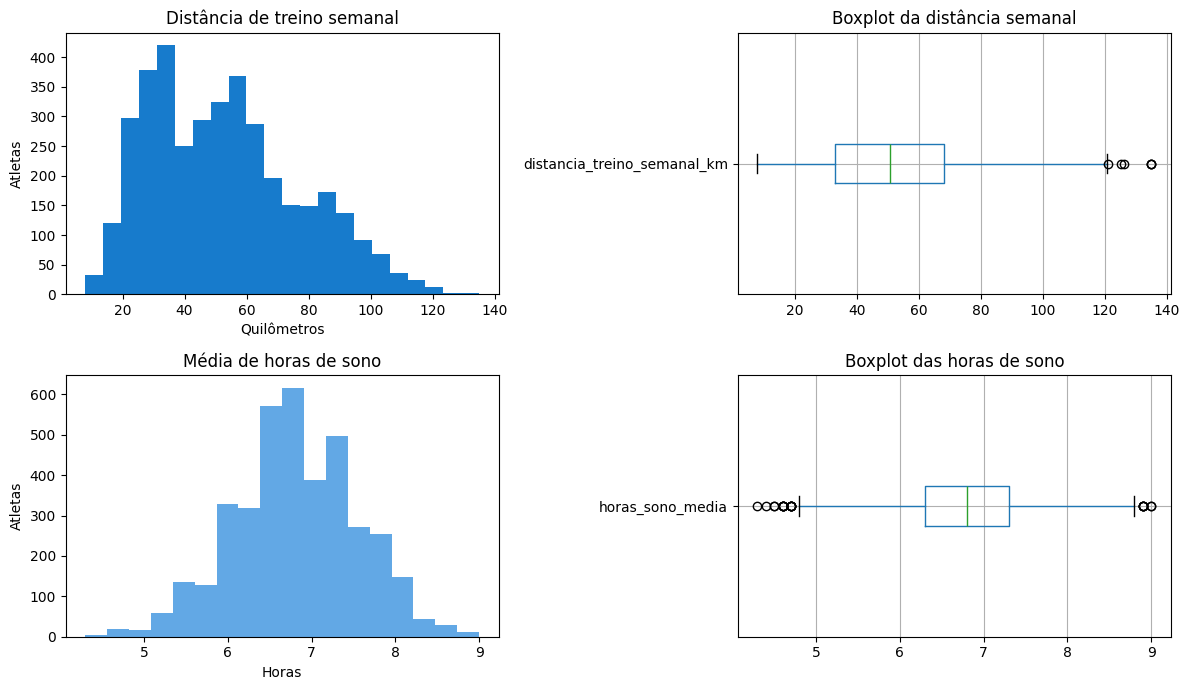

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

df["distancia_treino_semanal_km"].dropna().plot.hist(bins=22, color="#177BCC", ax=axes[0, 0])
axes[0, 0].set_title("Distância de treino semanal")
axes[0, 0].set_xlabel("Quilômetros")
axes[0, 0].set_ylabel("Atletas")
df.boxplot(column="distancia_treino_semanal_km", vert=False, ax=axes[0, 1])
axes[0, 1].set_title("Boxplot da distância semanal")

df["horas_sono_media"].dropna().plot.hist(bins=18, color="#62A8E5", ax=axes[1, 0])
axes[1, 0].set_title("Média de horas de sono")
axes[1, 0].set_xlabel("Horas")
axes[1, 0].set_ylabel("Atletas")
df.boxplot(column="horas_sono_media", vert=False, ax=axes[1, 1])
axes[1, 1].set_title("Boxplot das horas de sono")

plt.tight_layout()
plt.show()


## 6. Escolhendo e aplicando as medidas

A distância semanal apresenta cauda à direita, por isso usaremos a **mediana**. As horas de sono formam uma distribuição aproximadamente simétrica, então usaremos a **média**. Alguns pontos aparecem afastados no boxplot do sono, mas permanecem dentro do intervalo possível e não serão excluídos. Primeiro comparamos as medidas; depois fazemos o preenchimento.

In [7]:
print("Distância — média:", round(df["distancia_treino_semanal_km"].mean(), 2),
      "| mediana:", df["distancia_treino_semanal_km"].median())
print("Sono — média:", round(df["horas_sono_media"].mean(), 2),
      "| mediana:", df["horas_sono_media"].median())

mediana_distancia = df["distancia_treino_semanal_km"].median()
media_sono = df["horas_sono_media"].mean()

df["distancia_treino_semanal_km"] = df["distancia_treino_semanal_km"].fillna(mediana_distancia)
df["horas_sono_media"] = df["horas_sono_media"].fillna(media_sono)
df.isna().sum().sort_values(ascending=False).head()


Distância — média: 52.92 | mediana: 50.8
Sono — média: 6.81 | mediana: 6.8


,0
codigo_atleta,0
sexo,0
idade,0
experiencia_corrida_anos,0
nivel_preparo,0


## 7. Procurando anomalias na frequência cardíaca

Ausências preenchidas não garantem que todos os valores sejam possíveis. Vamos observar a distribuição e o boxplot antes de aplicar a regra do exercício.

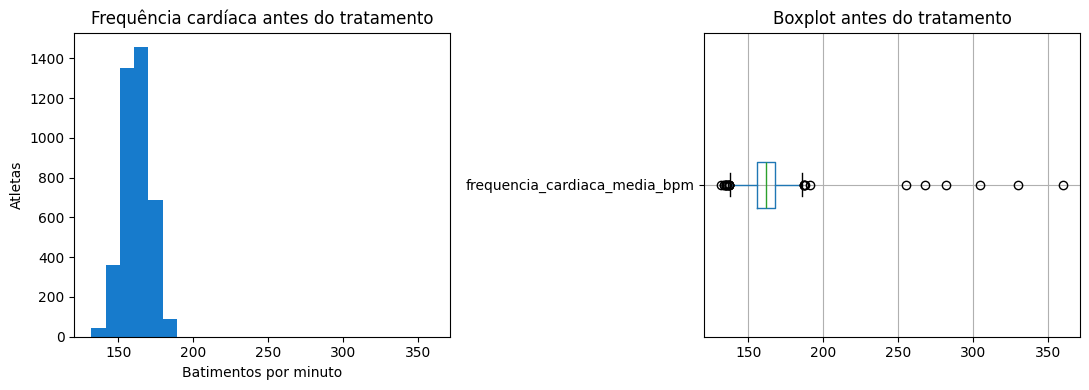

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["frequencia_cardiaca_media_bpm"].plot.hist(bins=24, color="#177BCC", ax=axes[0])
axes[0].set_title("Frequência cardíaca antes do tratamento")
axes[0].set_xlabel("Batimentos por minuto")
axes[0].set_ylabel("Atletas")
df.boxplot(column="frequencia_cardiaca_media_bpm", vert=False, ax=axes[1])
axes[1].set_title("Boxplot antes do tratamento")
plt.tight_layout()
plt.show()


## 8. Aplicando a regra de validade

Para esta base didática, aceitaremos frequências cardíacas médias entre **90 e 220 bpm**. O boxplot mostrou os pontos afastados; agora o limite conhecido confirma quais registros são inválidos.

In [9]:
frequencia_valida = df.loc[
    df["frequencia_cardiaca_media_bpm"].between(90, 220),
    "frequencia_cardiaca_media_bpm",
]
mediana_frequencia = frequencia_valida.median()

registros_invalidos = df.loc[
    ~df["frequencia_cardiaca_media_bpm"].between(90, 220),
    ["codigo_atleta", "frequencia_cardiaca_media_bpm"],
]
display(registros_invalidos)


,codigo_atleta,frequencia_cardiaca_media_bpm
1324,A1325,255
1908,A1909,268
3211,A3212,330
3421,A3422,305
3733,A3734,360
3778,A3779,282


## 9. Corrigindo e conferindo novamente

Como não temos a medição original, substituiremos somente os seis valores inválidos pela mediana dos valores válidos. Depois repetimos a inspeção visual. Pontos ainda destacados pelo boxplot, mas dentro do limite aceito, serão mantidos.

Tamanho final: (4000, 14)
Total de ausências: 0


,distancia_treino_semanal_km,horas_sono_media,frequencia_cardiaca_media_bpm
count,4000.00,4000.00,4000.00
mean,52.83,6.81,161.77
std,23.62,0.72,8.86
min,8.00,4.30,132.00
25%,33.40,6.30,156.00
50%,50.80,6.80,162.00
75%,67.00,7.30,168.00
max,135.00,9.00,191.00


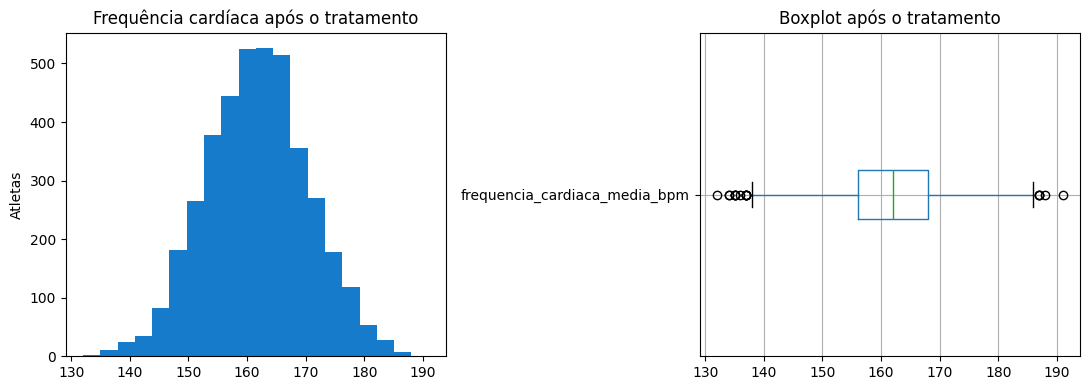

In [10]:
df.loc[
    ~df["frequencia_cardiaca_media_bpm"].between(90, 220),
    "frequencia_cardiaca_media_bpm",
] = mediana_frequencia

print("Tamanho final:", df.shape)
print("Total de ausências:", int(df.isna().sum().sum()))
display(df[["distancia_treino_semanal_km", "horas_sono_media", "frequencia_cardiaca_media_bpm"]].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["frequencia_cardiaca_media_bpm"].plot.hist(bins=20, color="#177BCC", ax=axes[0])
axes[0].set_title("Frequência cardíaca após o tratamento")
axes[0].set_ylabel("Atletas")
df.boxplot(column="frequencia_cardiaca_media_bpm", vert=False, ax=axes[1])
axes[1].set_title("Boxplot após o tratamento")
plt.tight_layout()
plt.show()


## 10. Observando o resultado por nível de preparo

Vamos comparar os percentuais de conclusão e abandono dentro de cada nível.

status_prova,Abandonou,Concluiu
nivel_preparo,,
Iniciante,9.7,90.3
Intermediário,2.8,97.2
Avançado,2.5,97.5


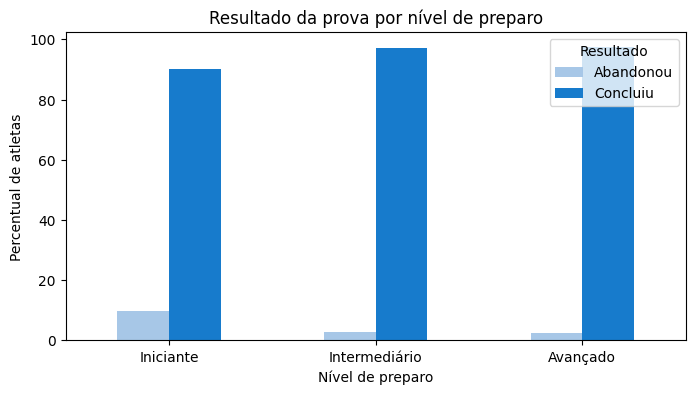

In [11]:
status_por_preparo = pd.crosstab(
    df["nivel_preparo"],
    df["status_prova"],
    normalize="index",
).mul(100).round(1)
status_por_preparo = status_por_preparo.reindex(["Iniciante", "Intermediário", "Avançado"])

display(status_por_preparo)
status_por_preparo.plot.bar(color=["#A7C7E7", "#177BCC"], rot=0, figsize=(8, 4))
plt.title("Resultado da prova por nível de preparo")
plt.ylabel("Percentual de atletas")
plt.xlabel("Nível de preparo")
plt.legend(title="Resultado")
plt.show()


## 11. Relações entre as variáveis dos concluintes

Tempo de prova só representa a conclusão quando o atleta terminou a maratona. Por isso, a análise abaixo utiliza apenas os concluintes. Correlação indica associação linear e não comprova causa.

,experiencia_corrida_anos,distancia_treino_semanal_km,ritmo_medio_treino_min_km,horas_sono_media,temperatura_prova_c,tempo_na_prova_min
experiencia_corrida_anos,1.00,0.69,-0.72,0.13,0.01,-0.68
distancia_treino_semanal_km,0.69,1.00,-0.86,0.17,0.01,-0.82
ritmo_medio_treino_min_km,-0.72,-0.86,1.00,-0.15,-0.02,0.95
horas_sono_media,0.13,0.17,-0.15,1.00,-0.00,-0.19
temperatura_prova_c,0.01,0.01,-0.02,-0.00,1.00,0.15
tempo_na_prova_min,-0.68,-0.82,0.95,-0.19,0.15,1.00


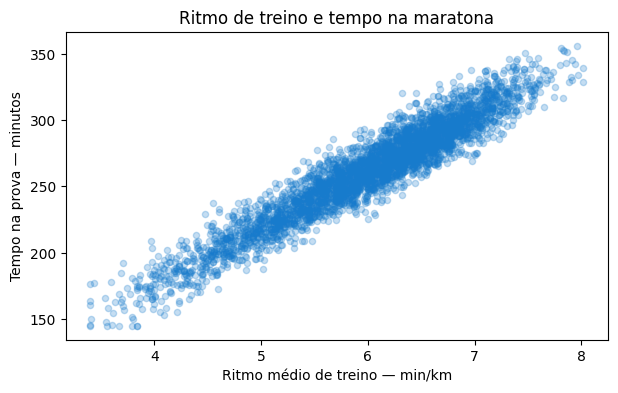

In [12]:
concluintes = df.loc[df["status_prova"] == "Concluiu"].copy()

colunas_correlacao = [
    "experiencia_corrida_anos",
    "distancia_treino_semanal_km",
    "ritmo_medio_treino_min_km",
    "horas_sono_media",
    "temperatura_prova_c",
    "tempo_na_prova_min",
]

display(concluintes[colunas_correlacao].corr().round(2))

concluintes.plot.scatter(
    x="ritmo_medio_treino_min_km",
    y="tempo_na_prova_min",
    alpha=0.25,
    color="#177BCC",
    figsize=(7, 4),
)
plt.title("Ritmo de treino e tempo na maratona")
plt.xlabel("Ritmo médio de treino — min/km")
plt.ylabel("Tempo na prova — minutos")
plt.show()


In [13]:
df.to_excel("aula_08_tratada.xlsx", index=False)
print("Base tratada salva com", df.shape[0], "linhas e", df.shape[1], "colunas.")


Base tratada salva com 4000 linhas e 14 colunas.


## 12. Desafio final

Agora é com vocês. Respondam às duas perguntas utilizando somente os comandos praticados nas aulas.

### Pergunta 1

Entre os atletas que concluíram a maratona, qual nível de preparo apresenta o menor **tempo mediano** na prova? Apresente o resultado por grupo e construa um boxplot para comparar as distribuições.

### Pergunta 2

Entre os concluintes, a distância de treino semanal está associada a tempos menores na maratona? Calcule a correlação, construa um gráfico de dispersão e explique o sentido da relação sem afirmar causalidade.